# 03 — Preprocessing

Scale `Time` and `Amount`, perform a stratified train/test split, and demonstrate SMOTE oversampling for the training set.

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

from src.data_preprocessing import load_data, scale_features, split_data, save_processed,save_processed_synthetic
from src.feature_engineering import apply_smote, compute_class_weight

In [4]:
df_raw = load_data()
print('Before scaling — Amount stats:')
print(df_raw[['Time', 'Amount']].describe())



Loaded 284,807 rows — 492 fraud, 284315 legitimate
Before scaling — Amount stats:
                Time         Amount
count  284807.000000  284807.000000
mean    94813.859575      88.349619
std     47488.145955     250.120109
min         0.000000       0.000000
25%     54201.500000       5.600000
50%     84692.000000      22.000000
75%    139320.500000      77.165000
max    172792.000000   25691.160000


## Scale Time and Amount

In [5]:
df = scale_features(df_raw)
# print(df.columns)
print('After scaling — Amount stats:')
print(df[['Time', 'Amount']].describe())

After scaling — Amount stats:
               Time        Amount
count  2.848070e+05  2.848070e+05
mean  -5.109395e-17 -3.672378e-17
std    1.000002e+00  1.000002e+00
min   -1.996583e+00 -3.532294e-01
25%   -8.552120e-01 -3.308401e-01
50%   -2.131453e-01 -2.652715e-01
75%    9.372174e-01 -4.471707e-02
max    1.642058e+00  1.023622e+02


## Stratified Train/Test Split (80/20)

In [6]:
X_train, X_test, y_train, y_test = split_data(df)
# print(f'\nClass balance preserved:')
# print(f'  Train fraud rate: {y_train.mean():.4%}')
# print(f'  Test  fraud rate: {y_test.mean():.4%}')


Train: 227,845 | Test: 56,962
Train fraud rate: 0.1729% | Test fraud rate: 0.1720%


## SMOTE Oversampling

We oversample only the training set to prevent data leakage. The test set remains untouched.

After SMOTE — fraud: 227,451 | legitimate: 227,451


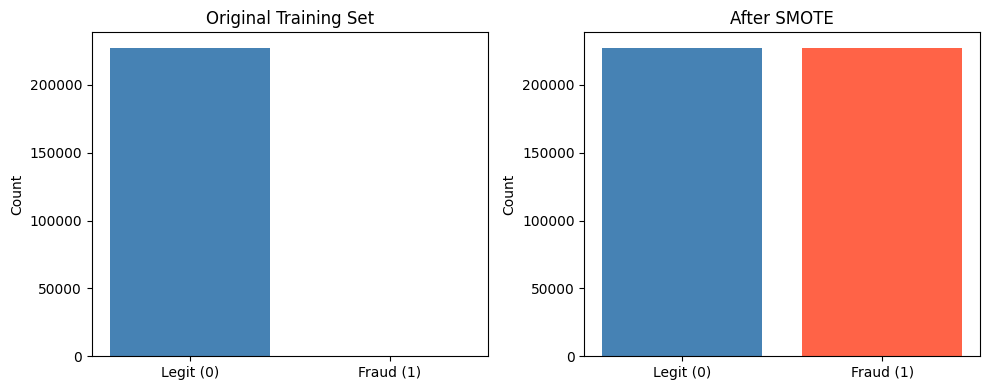

In [7]:
X_train_sm, y_train_sm = apply_smote(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (y, title) in zip(axes, [(y_train, 'Original Training Set'), (y_train_sm, 'After SMOTE')]):
    counts = y.value_counts()
    ax.bar(['Legit (0)', 'Fraud (1)'], counts.values, color=['steelblue', 'tomato'])
    ax.set_title(title)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## Alternative: Class Weights

Instead of resampling, most sklearn estimators accept `class_weight='balanced'` or an explicit dict.

In [8]:
cw = compute_class_weight(y_train)
print('Class weights:', cw)

Class weights: {0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}


## Save Processed Splits

In [9]:
print(len(y_train))
save_processed(X_train, X_test, y_train, y_test)
print('Done — splits saved to data/processed/')

227845
Processed splits saved to /home/suman/Documents/intern_project/credit_card_fraud_detection/src/../data/processed
Done — splits saved to data/processed/


# Save synthetic data

In [11]:

X_train_sm, y_train_sm = apply_smote(X_train, y_train)
save_processed_synthetic(X_train_sm,y_train_sm)


After SMOTE — fraud: 227,451 | legitimate: 227,451
Processed synthetic splits saved
